In [11]:
# =====================================================
# Cell 0 — Setup & Config
# =====================================================

import os
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

from typing import Optional, Tuple, Dict, List
import numpy as np
import matplotlib.pyplot as plt
import json, hashlib, re, time

from datasets import load_dataset, load_from_disk, Dataset, DatasetDict
from transformers import AutoTokenizer

# -------- CONFIG --------
DATASET_NAME   = "lmsys/lmsys-chat-1m"
SPLIT          = "train"
CACHE_DIR      = None
LOCAL_DS_PATH  = None  # e.g. "/data/lmsys_chat_1m"

TOKENIZER_NAME = "Qwen/Qwen2-7B"
LOCAL_FILES_ONLY = True

MAX_EXAMPLES   = 1000
LOG_EVERY      = 5_000
SHORT_TOKENS   = 64
LONG_TOKENS    = 1024

CACHE_ROOT = "./_len_cache"
os.makedirs(CACHE_ROOT, exist_ok=True)
CACHE_SCHEMA_VERSION = "v1"

print("Setup ready.")


Setup ready.


In [12]:
# =====================================================
# Cell 1 — Load Dataset (local only)
# =====================================================

def load_local_dataset() -> Dataset:
    if LOCAL_DS_PATH:
        print(f"Loading dataset from disk: {LOCAL_DS_PATH}")
        ds_dict = load_from_disk(LOCAL_DS_PATH)
        if isinstance(ds_dict, DatasetDict):
            return ds_dict[SPLIT]
        return ds_dict
    print(f"Loading from local HF cache: {DATASET_NAME} [{SPLIT}]")
    ds = load_dataset(
        DATASET_NAME,
        split=SPLIT,
        cache_dir=CACHE_DIR,
        streaming=False,
        trust_remote_code=False,
    )
    return ds

ds = load_local_dataset()
print(ds)


Using the latest cached version of the dataset since lmsys/lmsys-chat-1m couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at /home/saeid/.cache/huggingface/datasets/lmsys___lmsys-chat-1m/default/0.0.0/200748d9d3cddcc9d782887541057aca0b18c5da (last modified on Wed Oct 22 22:27:51 2025).


Loading from local HF cache: lmsys/lmsys-chat-1m [train]
Dataset({
    features: ['conversation_id', 'model', 'conversation', 'turn', 'language', 'openai_moderation', 'redacted'],
    num_rows: 1000000
})


In [13]:
# =====================================================
# Cell 2 — Tokenizer & Text Pair Extraction
# =====================================================

tok = AutoTokenizer.from_pretrained(TOKENIZER_NAME, local_files_only=LOCAL_FILES_ONLY)
try:
    tok.model_max_length = int(1e9)
except Exception:
    pass

def token_len(text: str) -> int:
    return len(tok.encode(text, add_special_tokens=False))

def _role(t): return (t.get("role") or t.get("from") or "").lower()
def _content(t): return (t.get("content") or t.get("value") or "").strip()

def _find_user_assistant_pair(conv: List[dict]) -> Optional[Tuple[str, str]]:
    last_user = None
    for i, turn in enumerate(conv):
        if _role(turn) in ("user", "human"):
            last_user = i
    if last_user is None:
        return None
    for j in range(last_user + 1, len(conv)):
        if _role(conv[j]) in ("assistant", "gpt", "bot"):
            u, a = _content(conv[last_user]), _content(conv[j])
            return (u, a) if (u and a) else None
    return None

def extract_pair(rec: dict) -> Optional[Tuple[str, str]]:
    for k in ("conversations", "conversation", "messages", "chat", "turns"):
        if k in rec and isinstance(rec[k], list):
            return _find_user_assistant_pair(rec[k])
    u = rec.get("user") or rec.get("prompt") or rec.get("question")
    a = rec.get("assistant") or rec.get("reply") or rec.get("answer")
    if isinstance(u, str) and isinstance(a, str) and u.strip() and a.strip():
        return (u.strip(), a.strip())
    return None


In [14]:
# =====================================================
# Cell 3 — Cache Utilities
# =====================================================

import json

def _slug(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s.strip())

def _fingerprint_of_dataset(ds) -> str:
    for attr in ("_fingerprint", "fingerprint"):
        if hasattr(ds, attr):
            v = getattr(ds, attr)
            if isinstance(v, str) and v:
                return v
    sig = json.dumps({
        "cols": sorted(getattr(ds, "column_names", [])),
        "n": len(ds) if hasattr(ds, "__len__") else "?"
    }, sort_keys=True)
    return hashlib.sha1(sig.encode("utf-8")).hexdigest()[:16]

def _make_cache_key(dataset_id: str, split: str, tokenizer_name: str, ds_fp: str, max_examples: Optional[int]) -> str:
    parts = [
        CACHE_SCHEMA_VERSION,
        _slug(dataset_id),
        _slug(split),
        _slug(tokenizer_name),
        _slug(ds_fp),
        f"max{max_examples if max_examples else 'all'}"
    ]
    return "__".join(parts)

def _cache_paths(key: str):
    npz_path  = os.path.join(CACHE_ROOT, f"{key}.npz")
    meta_path = os.path.join(CACHE_ROOT, f"{key}.meta.json")
    return npz_path, meta_path

def save_lengths_cache(key: str, input_lengths: List[int], output_lengths: List[int], meta: Dict):
    npz_path, meta_path = _cache_paths(key)
    np.savez_compressed(npz_path,
                        input_lengths=np.array(input_lengths, dtype=np.int32),
                        output_lengths=np.array(output_lengths, dtype=np.int32))
    meta = dict(meta)
    meta.update({
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "created_at": time.time(),
        "npz_path": npz_path,
    })
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    print(f"Saved cache: {npz_path}")

def try_load_lengths_cache(key: str):
    npz_path, meta_path = _cache_paths(key)
    if not (os.path.exists(npz_path) and os.path.exists(meta_path)):
        return None
    try:
        data = np.load(npz_path)
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        if meta.get("cache_schema_version") != CACHE_SCHEMA_VERSION:
            return None
        print(f"Loaded cached results: {npz_path}")
        return data["input_lengths"].tolist(), data["output_lengths"].tolist(), meta
    except Exception as e:
        print("Failed to load cache:", e)
        return None


In [15]:
# =====================================================
# Cell 4 — Get-or-Build Cached Lengths
# =====================================================

def get_or_build_lengths_with_cache(
    ds,
    dataset_id: str,
    split: str,
    tokenizer_name: str,
    max_examples: Optional[int],
    log_every: int = 5000
):
    ds_fp = _fingerprint_of_dataset(ds)
    key = _make_cache_key(dataset_id, split, tokenizer_name, ds_fp, max_examples)
    hit = try_load_lengths_cache(key)
    if hit is not None:
        in_l, out_l, meta = hit
        return in_l, out_l, meta, key

    print("Cache miss: computing token lengths...")
    input_lengths, output_lengths = [], []
    n_used = 0
    for rec in ds:
        pair = extract_pair(rec)
        if not pair:
            continue
        prompt, reply = pair
        in_len = token_len(prompt)
        out_len = token_len(reply)
        if in_len and out_len:
            input_lengths.append(in_len)
            output_lengths.append(out_len)
            n_used += 1
            if log_every and n_used % log_every == 0:
                print(f"[{n_used}] examples processed...")
        if max_examples and n_used >= max_examples:
            break

    meta = {
        "dataset_id": dataset_id,
        "split": split,
        "tokenizer_name": tokenizer_name,
        "dataset_fingerprint": ds_fp,
        "count": n_used,
        "max_examples": max_examples,
    }
    save_lengths_cache(key, input_lengths, output_lengths, meta)
    return input_lengths, output_lengths, meta, key


In [16]:
# =====================================================
# Cell 5 — Run (uses cache if present)
# =====================================================

DATASET_ID_FOR_KEY = DATASET_NAME if LOCAL_DS_PATH is None else f"disk:{LOCAL_DS_PATH}"

input_lengths, output_lengths, cache_meta, cache_key = get_or_build_lengths_with_cache(
    ds,
    dataset_id=DATASET_ID_FOR_KEY,
    split=SPLIT,
    tokenizer_name=TOKENIZER_NAME,
    max_examples=MAX_EXAMPLES,
    log_every=LOG_EVERY,
)

print(json.dumps(cache_meta, indent=2))
print("Cache key:", cache_key)


Cache miss: computing token lengths...


Saved cache: ./_len_cache/v1__lmsys_lmsys-chat-1m__train__Qwen_Qwen2-7B__631a709a5de07023__max1000.npz
{
  "dataset_id": "lmsys/lmsys-chat-1m",
  "split": "train",
  "tokenizer_name": "Qwen/Qwen2-7B",
  "dataset_fingerprint": "631a709a5de07023",
  "count": 1000,
  "max_examples": 1000
}
Cache key: v1__lmsys_lmsys-chat-1m__train__Qwen_Qwen2-7B__631a709a5de07023__max1000


In [17]:
# =====================================================
# Cell 6 — Statistics & Mix
# =====================================================

def describe(arr):
    a = np.array(arr, dtype=np.int64)
    return {
        "count": int(a.size),
        "mean": float(np.mean(a)),
        "std": float(np.std(a)),
        "min": int(np.min(a)),
        "p50": float(np.percentile(a, 50)),
        "p90": float(np.percentile(a, 90)),
        "p95": float(np.percentile(a, 95)),
        "p99": float(np.percentile(a, 99)),
        "max": int(np.max(a)),
    }

def mix_report(arr, short_thr, long_thr):
    a = np.array(arr)
    short = np.mean(a <= short_thr)
    long = np.mean(a >= long_thr)
    mid = 1 - short - long
    return {
        f"<= {short_thr}": round(100 * short, 2),
        f"{short_thr+1}..{long_thr-1}": round(100 * mid, 2),
        f">= {long_thr}": round(100 * long, 2),
    }

in_stats, out_stats = describe(input_lengths), describe(output_lengths)
in_mix, out_mix = mix_report(input_lengths, SHORT_TOKENS, LONG_TOKENS), mix_report(output_lengths, SHORT_TOKENS, LONG_TOKENS)

print("Input stats:", json.dumps(in_stats, indent=2))
print("Output stats:", json.dumps(out_stats, indent=2))
print("Input mix:", in_mix)
print("Output mix:", out_mix)


Input stats: {
  "count": 1000,
  "mean": 72.531,
  "std": 137.93951224721653,
  "min": 1,
  "p50": 20.0,
  "p90": 221.60000000000014,
  "p95": 351.0999999999999,
  "p99": 646.02,
  "max": 1692
}
Output stats: {
  "count": 1000,
  "mean": 191.8,
  "std": 164.99969696941872,
  "min": 1,
  "p50": 157.0,
  "p90": 425.20000000000005,
  "p95": 468.04999999999995,
  "p99": 656.03,
  "max": 1173
}
Input mix: {'<= 64': np.float64(76.1), '65..1023': np.float64(23.8), '>= 1024': np.float64(0.1)}
Output mix: {'<= 64': np.float64(29.5), '65..1023': np.float64(70.4), '>= 1024': np.float64(0.1)}


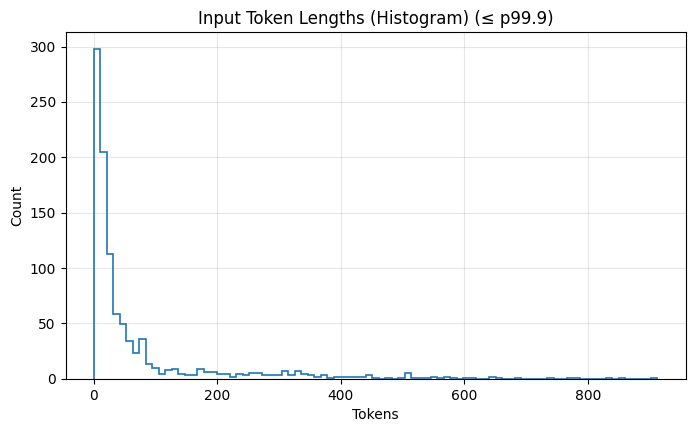

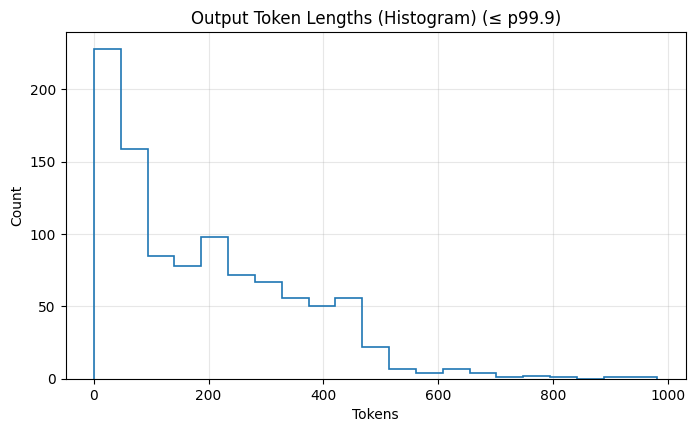

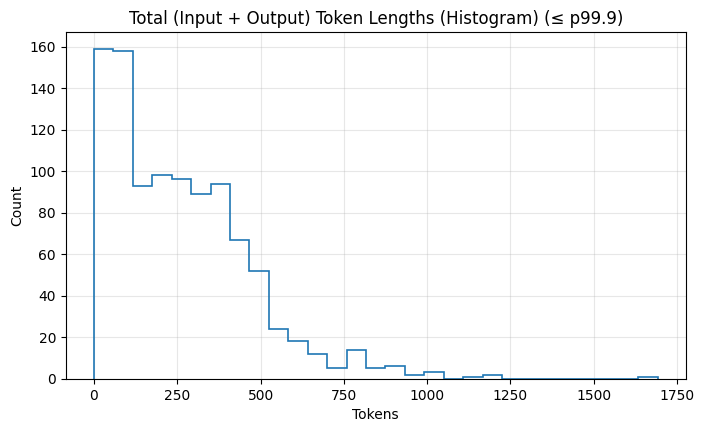

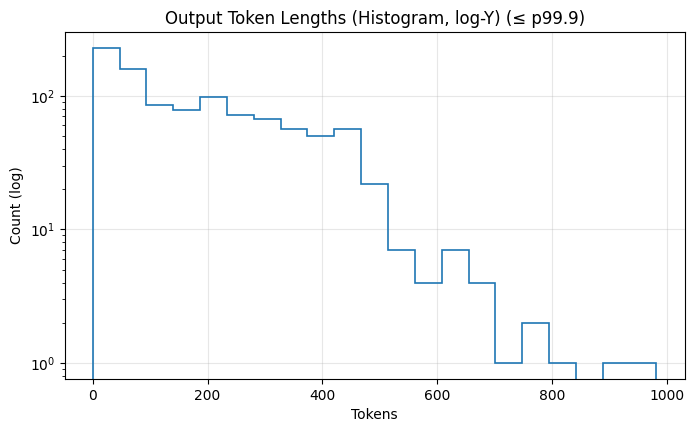

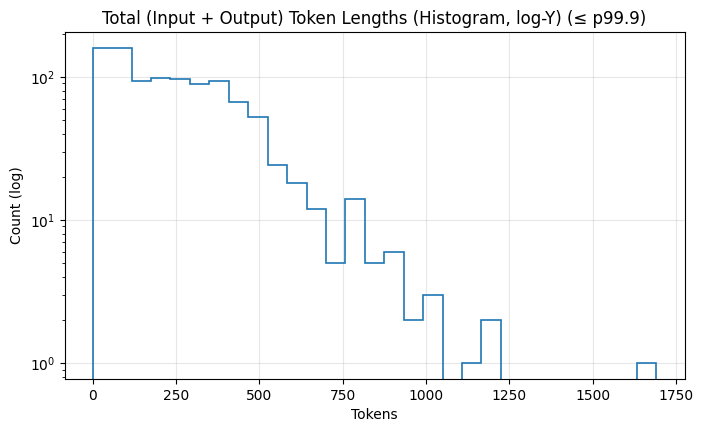

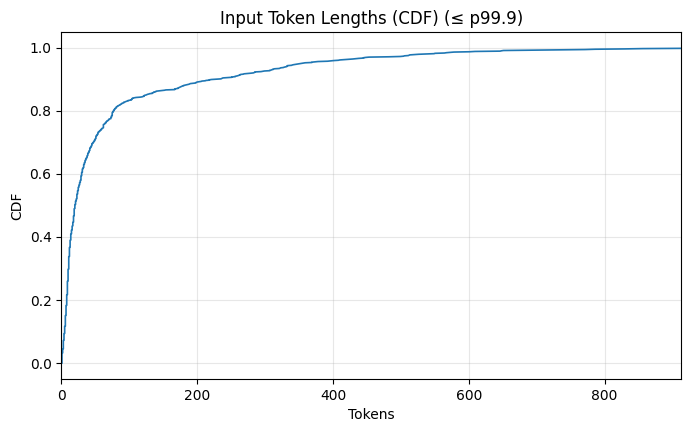

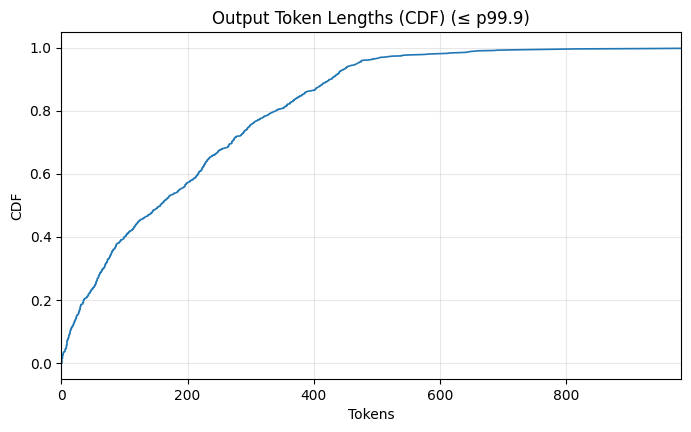

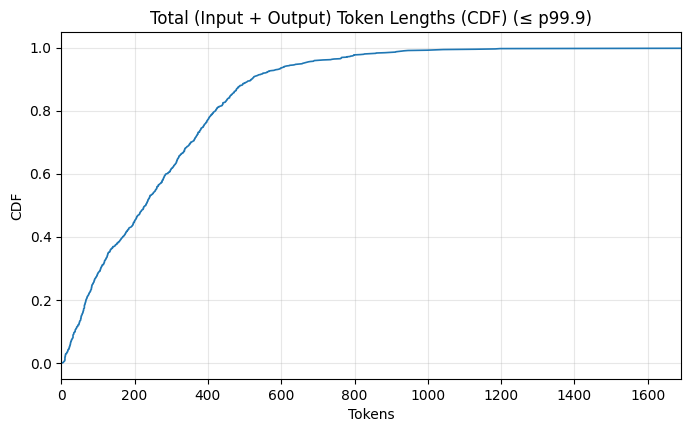


Input Lengths — summary
------------------------------------------------------------------------
count     : 1,000
min/max   : 1 / 1692
mean/std  : 72.53 / 137.94
p50/p90   : 20.00 / 221.60
p95/p99   : 351.10 / 646.02
p99.9     : 912.78

Output Lengths — summary
------------------------------------------------------------------------
count     : 1,000
min/max   : 1 / 1173
mean/std  : 191.80 / 165.00
p50/p90   : 157.00 / 425.20
p95/p99   : 468.05 / 656.03
p99.9     : 982.19

Total (Input + Output) Lengths — summary
------------------------------------------------------------------------
count     : 1,000
min/max   : 2 / 2170
mean/std  : 264.33 / 218.99
p50/p90   : 230.00 / 518.10
p95/p99   : 657.05 / 928.07
p99.9     : 1691.48

Input — fixed token bins
------------------------------------------------------------------------
           range |      count |  share% |    cum% |  mean_in_bin | median_in_bin
------------------------------------------------------------------------
       [0 

In [18]:
# =====================================================
# Cell 7 — Expanded Stats, Bucket Tables, Histograms & CDFs (plots first)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# -------------------------------
# Config
# -------------------------------
FIXED_BINS = [0, 32, 64, 128, 256, 512, 1024, 2048, 4096]
INCLUDE_INF_BIN = True
QUANTILE_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90]
PLOT_TRIM_PCT = 99.9


# -------------------------------
# Core helpers
# -------------------------------
def _safe_percentile(a: np.ndarray, p: float) -> float:
    return float(np.percentile(a, p)) if a.size else float("nan")

def _describe(arr: np.ndarray) -> dict:
    if arr.size == 0:
        return {}
    return {
        "count": int(arr.size),
        "min": int(arr.min()),
        "p50": _safe_percentile(arr, 50),
        "p90": _safe_percentile(arr, 90),
        "p95": _safe_percentile(arr, 95),
        "p99": _safe_percentile(arr, 99),
        "p99.9": _safe_percentile(arr, 99.9),
        "max": int(arr.max()),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
    }

def _print_summary(name: str, a: np.ndarray) -> None:
    if a.size == 0:
        print(f"[skip] {name}: no data")
        return
    s = _describe(a)
    print(f"\n{name} — summary")
    print("-" * 72)
    print(f"count     : {s['count']:,}")
    print(f"min/max   : {s['min']} / {s['max']}")
    print(f"mean/std  : {s['mean']:.2f} / {s['std']:.2f}")
    print(f"p50/p90   : {s['p50']:.2f} / {s['p90']:.2f}")
    print(f"p95/p99   : {s['p95']:.2f} / {s['p99']:.2f}")
    print(f"p99.9     : {s['p99.9']:.2f}")

def _fixed_bin_edges_for(a: np.ndarray, base_edges: List[int], include_inf: bool=True) -> np.ndarray:
    if a.size == 0:
        return np.array(base_edges, dtype=float)
    max_val = int(a.max())
    edges = list(sorted(set(base_edges)))
    if max_val > edges[-1]:
        edges.append(max_val + 1)
    if include_inf and np.isfinite(edges[-1]):
        edges.append(np.inf)
    return np.array(edges, dtype=float)

def _bucket_table_fixed(a: np.ndarray, edges: np.ndarray) -> List[dict]:
    if a.size == 0:
        return []
    finite_edges = np.copy(edges)
    finite_edges[-1] = np.inf
    total = a.size
    rows = []
    cum = 0
    for i in range(len(finite_edges) - 1):
        lo, hi = finite_edges[i], finite_edges[i + 1]
        mask = (a >= lo) & (a < hi)
        cnt = int(mask.sum())
        cum += cnt
        if cnt > 0:
            vals = a[mask]
            mean_v = float(vals.mean())
            med_v = float(np.median(vals))
        else:
            mean_v = float("nan")
            med_v = float("nan")
        rows.append({
            "range": f"[{int(lo)} .. {('inf' if np.isinf(hi) else int(hi-1))}]",
            "count": cnt,
            "share_pct": 100.0 * cnt / total if total else 0.0,
            "cum_share_pct": 100.0 * cum / total if total else 0.0,
            "mean_in_bin": mean_v,
            "median_in_bin": med_v,
        })
    return rows

def _bucket_table_quantiles(a: np.ndarray, pct_breaks: List[int]) -> Tuple[List[dict], List[float]]:
    if a.size == 0:
        return [], []
    cuts = [np.percentile(a, p) for p in pct_breaks]
    edges = np.array([a.min()] + cuts + [a.max()], dtype=float)
    edges = np.unique(edges)
    rows, total, cum = [], a.size, 0
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (a >= lo) & ((a <= hi) if i == len(edges) - 2 else (a < hi))
        cnt = int(mask.sum())
        cum += cnt
        if cnt > 0:
            vals = a[mask]
            mean_v = float(vals.mean())
            med_v = float(np.median(vals))
        else:
            mean_v = med_v = float("nan")
        rows.append({
            "range": f"[{int(lo)} .. {int(hi)}]",
            "count": cnt,
            "share_pct": 100.0 * cnt / total if total else 0.0,
            "cum_share_pct": 100.0 * cum / total if total else 0.0,
            "mean_in_bin": mean_v,
            "median_in_bin": med_v,
        })
    return rows, cuts

def _print_table(title: str, rows: List[dict], max_rows: int = 200):
    print(f"\n{title}")
    print("-" * 72)
    if not rows:
        print("[empty]")
        return
    print(f"{'range':>16} | {'count':>10} | {'share%':>7} | {'cum%':>7} | {'mean_in_bin':>12} | {'median_in_bin':>13}")
    print("-" * 72)
    for i, r in enumerate(rows[:max_rows]):
        print(f"{r['range']:>16} | {r['count']:>10,} | {r['share_pct']:>7.2f} | {r['cum_share_pct']:>7.2f} | {r['mean_in_bin']:>12.2f} | {r['median_in_bin']:>13.2f}")

def _plot_hist(data, title, bins="fd", trim_pct=PLOT_TRIM_PCT, logy=False, density=False):
    if data is None or len(data) == 0:
        print(f"[skip] {title}: no data")
        return
    arr = np.asarray(data)
    cap = np.percentile(arr, trim_pct)
    plt.figure(figsize=(8, 4.5))
    plt.hist(arr, bins=bins, range=(0, cap), histtype="step", linewidth=1.2, density=density)
    if logy:
        plt.yscale("log")
    ylab = ("Density" if density else "Count") + (" (log)" if logy else "")
    plt.title(f"{title} (≤ p{trim_pct})")
    plt.xlabel("Tokens")
    plt.ylabel(ylab)
    plt.grid(True, alpha=0.3)
    plt.show()

def _plot_cdf(data, title, trim_pct=PLOT_TRIM_PCT):
    if data is None or len(data) == 0:
        print(f"[skip] {title}: no data")
        return
    a = np.sort(np.asarray(data))
    y = np.linspace(0, 1, len(a), endpoint=False)
    cap = np.percentile(a, trim_pct)
    plt.figure(figsize=(8, 4.5))
    plt.plot(a, y, linewidth=1.2)
    plt.title(f"{title} (≤ p{trim_pct})")
    plt.xlabel("Tokens")
    plt.ylabel("CDF")
    plt.xlim(0, cap)
    plt.grid(True, alpha=0.3)
    plt.show()


# -------------------------------
# Prepare arrays
# -------------------------------
in_arr  = np.asarray(input_lengths, dtype=np.int64)
out_arr = np.asarray(output_lengths, dtype=np.int64)
tot_arr = np.asarray(np.array(input_lengths) + np.array(output_lengths), dtype=np.int64)


# -------------------------------
# Plots FIRST (for readability)
# -------------------------------
_plot_hist(in_arr,  "Input Token Lengths (Histogram)")
_plot_hist(out_arr, "Output Token Lengths (Histogram)")
_plot_hist(tot_arr, "Total (Input + Output) Token Lengths (Histogram)")
_plot_hist(out_arr, "Output Token Lengths (Histogram, log-Y)", logy=True)
_plot_hist(tot_arr, "Total (Input + Output) Token Lengths (Histogram, log-Y)", logy=True)

_plot_cdf(in_arr,  "Input Token Lengths (CDF)")
_plot_cdf(out_arr, "Output Token Lengths (CDF)")
_plot_cdf(tot_arr, "Total (Input + Output) Token Lengths (CDF)")


# -------------------------------
# THEN — Print expanded summaries
# -------------------------------
_print_summary("Input Lengths", in_arr)
_print_summary("Output Lengths", out_arr)
_print_summary("Total (Input + Output) Lengths", tot_arr)

edges_in  = _fixed_bin_edges_for(in_arr,  FIXED_BINS, include_inf=INCLUDE_INF_BIN)
edges_out = _fixed_bin_edges_for(out_arr, FIXED_BINS, include_inf=INCLUDE_INF_BIN)
edges_tot = _fixed_bin_edges_for(tot_arr, FIXED_BINS, include_inf=INCLUDE_INF_BIN)

rows_in_fixed  = _bucket_table_fixed(in_arr,  edges_in)
rows_out_fixed = _bucket_table_fixed(out_arr, edges_out)
rows_tot_fixed = _bucket_table_fixed(tot_arr, edges_tot)

_print_table("Input — fixed token bins",  rows_in_fixed)
_print_table("Output — fixed token bins", rows_out_fixed)
_print_table("Total  — fixed token bins", rows_tot_fixed)

rows_in_q,  cuts_in  = _bucket_table_quantiles(in_arr,  QUANTILE_PCTS)
rows_out_q, cuts_out = _bucket_table_quantiles(out_arr, QUANTILE_PCTS)
rows_tot_q, cuts_tot = _bucket_table_quantiles(tot_arr, QUANTILE_PCTS)

_print_table("Input — quantile bins",  rows_in_q)
_print_table("Output — quantile bins", rows_out_q)
_print_table("Total  — quantile bins", rows_tot_q)

print("\nQuantile cut points (approx):")
print(f"Input  cuts @ {QUANTILE_PCTS}: {[int(x) for x in cuts_in]}")
print(f"Output cuts @ {QUANTILE_PCTS}: {[int(x) for x in cuts_out]}")
print(f"Total  cuts @ {QUANTILE_PCTS}: {[int(x) for x in cuts_tot]}")


In [27]:
# =====================================================
# Cell 8 — Pull vs Push Benefit Potential (under given batch size)
# =====================================================

# ---- Config ----
BATCH_SIZE = 1024  # ← set your target batch size here

def analyze_pull_push_potential(in_arr, out_arr, tot_arr, batch_size=BATCH_SIZE):
    """
    Estimate whether pull batching could outperform push batching given
    request length variability within a fixed batch size.
    """
    print(f"=== Pull vs Push Benefit Potential (Batch size = {batch_size}) ===\n")

    def analyze_dimension(arr, label):
        if arr is None or len(arr) == 0:
            print(f"[skip] {label}: no data")
            return None

        # Core stats
        mean = np.mean(arr)
        std = np.std(arr)
        cov = std / mean if mean > 0 else 0
        p95 = np.percentile(arr, 95)
        p99 = np.percentile(arr, 99)

        # Simulate push inefficiency: in push, batch latency = longest item in batch
        # We approximate expected wasted work per batch from variability.
        # Coefficient of variation (CoV) is a good proxy for inefficiency.
        ineff = min(100, cov * 100)  # cap at 100% for readability

        print(f"{label}:")
        print(f"  mean={mean:.1f}  std={std:.1f}  CoV={cov:.2f}")
        print(f"  p95={p95:.1f}  p99={p99:.1f}")
        print(f"  → estimated inefficiency (push waste vs pull) ≈ {ineff:.1f}%")

        if cov < 0.2:
            verdict = "Uniform lengths — minimal difference expected."
        elif cov < 0.5:
            verdict = "Moderate heterogeneity — pull may yield mild throughput gains."
        elif cov < 1.0:
            verdict = "High variability — pull batching likely beneficial."
        else:
            verdict = "Extreme heterogeneity — pull should outperform push strongly."

        # Estimate wasted tokens fraction per batch (simplified heuristic)
        mean_len = mean
        long_tail_factor = (p99 / mean) if mean > 0 else 0
        est_waste = min(100, (long_tail_factor - 1) * 10)
        print(f"  → long-tail factor (p99/mean): {long_tail_factor:.2f}")
        print(f"  → rough wasted-capacity proxy: {est_waste:.1f}%")
        print(f"  Summary: {verdict}\n")
        return {"label": label, "cov": cov, "ineff": ineff, "verdict": verdict}

    results = [
        analyze_dimension(in_arr,  "Input Lengths"),
        analyze_dimension(out_arr, "Output Lengths"),
        analyze_dimension(tot_arr, "Total (Input+Output)"),
    ]

    # Overall signal
    covs = [r["cov"] for r in results if r]
    mean_cov = np.mean(covs) if covs else 0
    print("=== Overall Assessment ===")
    if mean_cov < 0.2:
        print("→ Distribution is tight and uniform — Push-based batching is fine.")
    elif mean_cov < 0.5:
        print("→ Some variation detected — Pull may slightly improve GPU utilization.")
    else:
        print("→ High token-length variance — Pull-based batching likely provides real throughput benefit.")

# Run the analysis
analyze_pull_push_potential(in_arr, out_arr, tot_arr)


=== Pull vs Push Benefit Potential (Batch size = 1024) ===

Input Lengths:
  mean=72.5  std=137.9  CoV=1.90
  p95=351.1  p99=646.0
  → estimated inefficiency (push waste vs pull) ≈ 100.0%
  → long-tail factor (p99/mean): 8.91
  → rough wasted-capacity proxy: 79.1%
  Summary: Extreme heterogeneity — pull should outperform push strongly.

Output Lengths:
  mean=191.8  std=165.0  CoV=0.86
  p95=468.0  p99=656.0
  → estimated inefficiency (push waste vs pull) ≈ 86.0%
  → long-tail factor (p99/mean): 3.42
  → rough wasted-capacity proxy: 24.2%
  Summary: High variability — pull batching likely beneficial.

Total (Input+Output):
  mean=264.3  std=219.0  CoV=0.83
  p95=657.0  p99=928.1
  → estimated inefficiency (push waste vs pull) ≈ 82.8%
  → long-tail factor (p99/mean): 3.51
  → rough wasted-capacity proxy: 25.1%
  Summary: High variability — pull batching likely beneficial.

=== Overall Assessment ===
→ High token-length variance — Pull-based batching likely provides real throughput benef

In [20]:
# =====================================================
# Cell 9 — Sanity checks for output_lengths
# =====================================================
import numpy as np

ol = np.asarray(output_lengths)
print({
    "count": int(ol.size),
    "dtype": str(ol.dtype),
    "min": int(ol.min()) if ol.size else None,
    "max": int(ol.max()) if ol.size else None,
    "mean": float(ol.mean()) if ol.size else None,
    "p50": float(np.percentile(ol, 50)) if ol.size else None,
    "p90": float(np.percentile(ol, 90)) if ol.size else None,
    "p95": float(np.percentile(ol, 95)) if ol.size else None,
    "p99": float(np.percentile(ol, 99)) if ol.size else None,
    "unique_values": int(np.unique(ol).size)
})
print("zeros:", int((ol==0).sum()))


{'count': 1000, 'dtype': 'int64', 'min': 1, 'max': 1173, 'mean': 191.8, 'p50': 157.0, 'p90': 425.20000000000005, 'p95': 468.04999999999995, 'p99': 656.03, 'unique_values': 426}
zeros: 0
